# Final Forecast and Business Insights

Evaluate the selected model on the untouched holdout, retrain on all historical data, generate the final 8-week store-level forecast, and summarize business implications.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [2]:
def find_project_root():
    path = Path.cwd().resolve()

    for candidate in [path, *path.parents]:
        if (candidate / "data" / "raw").exists():
            return candidate

    raise FileNotFoundError("Project root not found")


PROJECT_ROOT = find_project_root()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

In [3]:
model_data = pd.read_csv(
    PROCESSED_DIR / "store_week_features.csv"
)

model_data["Date"] = pd.to_datetime(
    model_data["Date"]
)

model_data = (
    model_data
    .sort_values(["Store", "Date"])
    .reset_index(drop=True)
)

model_data.shape

(4095, 25)

In [4]:
features = pd.read_csv(
    RAW_DIR / "features.csv"
)

stores = pd.read_csv(
    RAW_DIR / "stores.csv"
)

features["Date"] = pd.to_datetime(
    features["Date"]
)

## Final Holdout

The period from 2012-09-28 to 2012-10-26 is reserved as an untouched historical holdout.

It is evaluated before the selected model is retrained on all available historical data.

In [5]:
holdout_start = pd.Timestamp("2012-09-28")
holdout_end = pd.Timestamp("2012-10-26")

holdout_dates = pd.date_range(
    holdout_start,
    holdout_end,
    freq="7D"
)

assert len(holdout_dates) == 5

print(
    "Holdout:",
    holdout_start.date(),
    "to",
    holdout_end.date()
)

Holdout: 2012-09-28 to 2012-10-26


In [6]:
development_data = model_data[
    model_data["Date"] < holdout_start
].copy()

holdout_data = model_data[
    model_data["Date"].between(
        holdout_start,
        holdout_end
    )
].copy()

assert len(holdout_data) == 225
assert holdout_data["Store"].nunique() == 45

print("Development rows:", len(development_data))
print("Holdout rows:", len(holdout_data))

Development rows: 3870
Holdout rows: 225


## Selected Model

Gradient Boosting with Core + External features was selected during rolling backtesting based on the lowest average WAPE and stable performance across windows.

In [7]:
target = "Weekly_Sales"

core_numeric_features = [
    "lag_1",
    "lag_2",
    "lag_52",
    "rolling_mean_4",
    "rolling_std_4",
    "WeekOfYear",
    "Month",
    "Size"
]

core_categorical_features = [
    "HolidayName",
    "Type"
]

external_features = [
    "Temperature",
    "Fuel_Price",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
    "CPI",
    "Unemployment"
]

external_features = [
    col
    for col in external_features
    if col in model_data.columns
]

selected_numeric_features = (
    core_numeric_features
    + external_features
)

selected_categorical_features = (
    core_categorical_features
)

selected_feature_columns = (
    selected_numeric_features
    + selected_categorical_features
)

In [8]:
def build_model(
    numeric_features,
    categorical_features
):

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median")
            )
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_features
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_features
            )
        ]
    )

    model = GradientBoostingRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        random_state=42
    )

    return Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

In [9]:
def wape(actual, forecast):

    actual = np.asarray(actual)
    forecast = np.asarray(forecast)

    denominator = np.abs(actual).sum()

    if denominator == 0:
        return np.nan

    return (
        np.abs(actual - forecast).sum()
        / denominator
    )

In [10]:
def evaluate_forecast(actual, forecast):

    return {
        "MAE": mean_absolute_error(
            actual,
            forecast
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                actual,
                forecast
            )
        ),
        "WAPE": wape(
            actual,
            forecast
        )
    }

In [11]:
holiday_map = {
    "2010-02-12": "Super Bowl",
    "2010-09-10": "Labor Day",
    "2010-11-26": "Thanksgiving",
    "2010-12-31": "Christmas",
    "2011-02-11": "Super Bowl",
    "2011-09-09": "Labor Day",
    "2011-11-25": "Thanksgiving",
    "2011-12-30": "Christmas",
    "2012-02-10": "Super Bowl",
    "2012-09-07": "Labor Day",
    "2012-11-23": "Thanksgiving",
    "2012-12-28": "Christmas"
}

In [12]:
def prepare_calendar(data):

    calendar = data[
        [
            "Store",
            "Date",
            "Temperature",
            "Fuel_Price",
            "MarkDown1",
            "MarkDown2",
            "MarkDown3",
            "MarkDown4",
            "MarkDown5",
            "CPI",
            "Unemployment"
        ]
    ].copy()

    calendar["WeekOfYear"] = (
        calendar["Date"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

    calendar["Month"] = (
        calendar["Date"].dt.month
    )

    calendar["HolidayName"] = (
        calendar["Date"]
        .dt.strftime("%Y-%m-%d")
        .map(holiday_map)
    )

    calendar = calendar.merge(
        stores[
            ["Store", "Type", "Size"]
        ],
        on="Store",
        how="left",
        validate="many_to_one"
    )

    return calendar

In [13]:
holdout_calendar = prepare_calendar(
    features
)

holdout_calendar = holdout_calendar[
    holdout_calendar["Date"].between(
        holdout_start,
        holdout_end
    )
].copy()

assert len(holdout_calendar) == 225
assert holdout_calendar["Store"].nunique() == 45
assert not holdout_calendar.duplicated(
    ["Store", "Date"]
).any()

In [14]:
def recursive_forecast(
    model,
    history,
    future_calendar,
    feature_columns
):

    history = (
        history[
            ["Store", "Date", "Weekly_Sales"]
        ]
        .copy()
        .sort_values(["Store", "Date"])
    )

    predictions = []

    for date in sorted(
        future_calendar["Date"].unique()
    ):

        current_calendar = future_calendar[
            future_calendar["Date"] == date
        ].copy()

        rows = []

        for store_id in sorted(
            history["Store"].unique()
        ):

            store_history = (
                history[
                    history["Store"] == store_id
                ]
                .sort_values("Date")
                .reset_index(drop=True)
            )

            sales = store_history[
                "Weekly_Sales"
            ]

            assert len(sales) >= 52

            calendar_row = current_calendar[
                current_calendar["Store"]
                == store_id
            ].iloc[0]

            row = {
                "Store": store_id,
                "Date": date,
                "lag_1": sales.iloc[-1],
                "lag_2": sales.iloc[-2],
                "lag_52": sales.iloc[-52],
                "rolling_mean_4": sales.iloc[-4:].mean(),
                "rolling_std_4": sales.iloc[-4:].std(),
                "WeekOfYear": calendar_row["WeekOfYear"],
                "Month": calendar_row["Month"],
                "HolidayName": calendar_row["HolidayName"],
                "Type": calendar_row["Type"],
                "Size": calendar_row["Size"]
            }

            for col in external_features:
                row[col] = calendar_row[col]

            rows.append(row)

        feature_frame = pd.DataFrame(rows)

        feature_frame["HolidayName"] = (
            feature_frame["HolidayName"]
            .fillna("None")
            .astype(str)
        )

        feature_frame["Type"] = (
            feature_frame["Type"]
            .fillna("None")
            .astype(str)
        )

        forecast_values = model.predict(
            feature_frame[feature_columns]
        )

        for row, prediction in zip(
            rows,
            forecast_values
        ):

            predictions.append({
                "Store": row["Store"],
                "Date": date,
                "Forecast": prediction
            })

            history = pd.concat(
                [
                    history,
                    pd.DataFrame(
                        [{
                            "Store": row["Store"],
                            "Date": date,
                            "Weekly_Sales": prediction
                        }]
                    )
                ],
                ignore_index=True
            )

    return pd.DataFrame(predictions)

In [15]:
holdout_training = development_data[
    [
        target,
        *selected_feature_columns
    ]
].dropna(
    subset=[target]
)

holdout_model = build_model(
    selected_numeric_features,
    selected_categorical_features
)

holdout_model.fit(
    holdout_training[selected_feature_columns],
    holdout_training[target]
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['lag_1','lag_2','lag_52',...,'Unemployment','HolidayName','Type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of 

In [16]:
holdout_forecast = recursive_forecast(
    holdout_model,
    development_data,
    holdout_calendar,
    selected_feature_columns
)

assert len(holdout_forecast) == 225

In [17]:
holdout_evaluation = holdout_forecast.merge(
    holdout_data[
        ["Store", "Date", "Weekly_Sales"]
    ],
    on=["Store", "Date"],
    how="left",
    validate="one_to_one"
)

assert (
    holdout_evaluation["Weekly_Sales"]
    .notna()
    .all()
)

holdout_metrics = evaluate_forecast(
    holdout_evaluation["Weekly_Sales"],
    holdout_evaluation["Forecast"]
)

holdout_metrics

{'MAE': 47030.416524032626,
 'RMSE': np.float64(72006.90642446007),
 'WAPE': np.float64(0.04639194382597885)}

## Final Holdout Performance

The holdout metrics represent performance on historical observations that were not used during rolling model selection.

In [18]:
holdout_summary = pd.DataFrame(
    [holdout_metrics],
    index=["Gradient Boosting - Core + External"]
)

holdout_summary

,MAE,RMSE,WAPE
Gradient Boosting - Core + External,47030.416524,72006.906424,0.046392


In [19]:
print(
    f"Final holdout WAPE: "
    f"{holdout_metrics['WAPE']:.2%}"
)

Final holdout WAPE: 4.64%


## Final Model Retraining

After holdout evaluation, the selected model is retrained using all available historical modeling data through 2012-10-26.

In [20]:
final_training = model_data[
    [
        target,
        *selected_feature_columns
    ]
].dropna(
    subset=[target]
)

final_model = build_model(
    selected_numeric_features,
    selected_categorical_features
)

final_model.fit(
    final_training[selected_feature_columns],
    final_training[target]
)

print(
    "Final model trained on",
    len(final_training),
    "historical rows."
)

Final model trained on 4095 historical rows.


## Final 8-Week Forecast

The final forecast covers 2012-11-02 through 2012-12-21 for all 45 stores.

In [21]:
forecast_dates = pd.date_range(
    "2012-11-02",
    "2012-12-21",
    freq="7D"
)

assert len(forecast_dates) == 8

print(
    forecast_dates.min().date(),
    "to",
    forecast_dates.max().date()
)

2012-11-02 to 2012-12-21


In [22]:
future_calendar = prepare_calendar(
    features
)

future_calendar = future_calendar[
    future_calendar["Date"].isin(
        forecast_dates
    )
].copy()

assert len(future_calendar) == 360
assert future_calendar["Store"].nunique() == 45
assert future_calendar["Date"].nunique() == 8

assert not future_calendar.duplicated(
    ["Store", "Date"]
).any()

In [23]:
future_forecast = recursive_forecast(
    final_model,
    model_data,
    future_calendar,
    selected_feature_columns
)

assert len(future_forecast) == 360

assert future_forecast[
    ["Store", "Date"]
].duplicated().sum() == 0

assert future_forecast["Forecast"].notna().all()

In [24]:
forecast_summary = (
    future_forecast
    .groupby("Store")
    .agg(
        Total_Forecast=(
            "Forecast",
            "sum"
        ),
        Average_Weekly_Forecast=(
            "Forecast",
            "mean"
        ),
        Peak_Weekly_Forecast=(
            "Forecast",
            "max"
        )
    )
    .sort_values(
        "Total_Forecast",
        ascending=False
    )
)

forecast_summary.head(10)

,Total_Forecast,Average_Weekly_Forecast,Peak_Weekly_Forecast
Store,,,
4,2.034564e+07,2.543205e+06,3.449342e+06
20,1.988714e+07,2.485893e+06,3.334511e+06
13,1.984365e+07,2.480456e+06,3.473037e+06
10,1.899162e+07,2.373952e+06,3.343422e+06
14,1.850249e+07,2.312811e+06,3.340067e+06
2,1.787895e+07,2.234869e+06,2.742837e+06
27,1.597007e+07,1.996258e+06,2.410316e+06
6,1.568255e+07,1.960319e+06,2.613106e+06
39,1.546922e+07,1.933652e+06,2.445533e+06


In [25]:
weekly_forecast = (
    future_forecast
    .groupby("Date")["Forecast"]
    .sum()
    .reset_index()
)

weekly_forecast

,Date,Forecast
0,2012-11-02,4.923771e+07
1,2012-11-09,4.964133e+07
2,2012-11-16,4.874881e+07
3,2012-11-23,6.587199e+07
4,2012-11-30,5.157078e+07
5,2012-12-07,5.638476e+07
6,2012-12-14,5.953520e+07
7,2012-12-21,7.285782e+07


## Forecast Trend

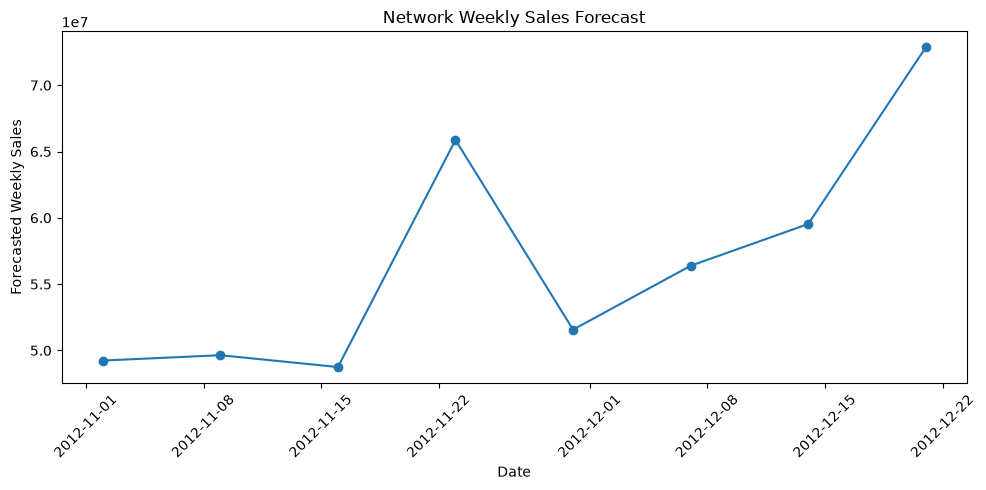

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    weekly_forecast["Date"],
    weekly_forecast["Forecast"],
    marker="o"
)

plt.title("Network Weekly Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Forecasted Weekly Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Store-Level Decision Support

In [27]:
top_stores = (
    forecast_summary
    .head(10)
)

top_stores

,Total_Forecast,Average_Weekly_Forecast,Peak_Weekly_Forecast
Store,,,
4,2.034564e+07,2.543205e+06,3.449342e+06
20,1.988714e+07,2.485893e+06,3.334511e+06
13,1.984365e+07,2.480456e+06,3.473037e+06
10,1.899162e+07,2.373952e+06,3.343422e+06
14,1.850249e+07,2.312811e+06,3.340067e+06
2,1.787895e+07,2.234869e+06,2.742837e+06
27,1.597007e+07,1.996258e+06,2.410316e+06
6,1.568255e+07,1.960319e+06,2.613106e+06
39,1.546922e+07,1.933652e+06,2.445533e+06


In [28]:
store_type_map = stores[
    ["Store", "Type"]
]

forecast_by_type = (
    future_forecast
    .merge(
        store_type_map,
        on="Store",
        how="left",
        validate="many_to_one"
    )
    .groupby("Type")
    ["Forecast"]
    .sum()
    .sort_values(
        ascending=False
    )
)

forecast_by_type

Type
A    2.891373e+08
B    1.405320e+08
C    2.417914e+07
Name: Forecast, dtype: float64

In [29]:
peak_week = weekly_forecast.loc[
    weekly_forecast["Forecast"].idxmax()
]

print(
    "Peak forecast week:",
    peak_week["Date"].date()
)

print(
    f"Forecasted sales: "
    f"{peak_week['Forecast']:,.0f}"
)

Peak forecast week: 2012-12-21
Forecasted sales: 72,857,822


In [30]:
holiday_forecast = (
    future_calendar[
        future_calendar["HolidayName"].notna()
    ][
        ["Date", "HolidayName"]
    ]
    .drop_duplicates()
)

holiday_forecast

,Date,HolidayName
146,2012-11-23,Thanksgiving


## Business Insights

- The selected Gradient Boosting model outperformed the Seasonal Naive benchmark during rolling 8-week backtesting.
- External variables improved development-period forecasting performance and were retained in the final model.
- Store-level forecast demand is concentrated in the highest-volume stores, supporting differentiated inventory and staffing decisions.
- The forecast shows elevated network demand around Thanksgiving and the year-end period.
- Store 4 has the highest projected 8-week sales and should receive higher operational planning attention.
- Store-level error diagnostics highlight locations that may require additional forecasting attention.

In [31]:
top_store = forecast_summary.index[0]

top_store_sales = (
    forecast_summary.iloc[0]["Total_Forecast"]
)

total_network_forecast = (
    future_forecast["Forecast"].sum()
)

print(
    f"8-week network forecast: "
    f"{total_network_forecast:,.0f}"
)

print(
    f"Highest forecast store: "
    f"Store {top_store}"
)

print(
    f"Store {top_store} forecast: "
    f"{top_store_sales:,.0f}"
)

8-week network forecast: 453,848,403
Highest forecast store: Store 4
Store 4 forecast: 20,345,637


## Save Forecast Outputs

In [32]:
future_forecast.to_csv(
    PROCESSED_DIR / "future_forecast.csv",
    index=False
)

forecast_summary.to_csv(
    PROCESSED_DIR / "forecast_summary.csv"
)

weekly_forecast.to_csv(
    PROCESSED_DIR / "weekly_forecast.csv",
    index=False
)

In [33]:
assert len(future_forecast) == 360

assert (
    future_forecast["Store"].nunique()
    == 45
)

assert (
    future_forecast["Date"].nunique()
    == 8
)

assert (
    future_forecast["Forecast"]
    .notna()
    .all()
)

assert (
    future_forecast[
        ["Store", "Date"]
    ]
    .duplicated()
    .sum()
    == 0
)

print("Final forecast validation passed.")

Final forecast validation passed.


## Final Output

The final deliverables include:

- Untouched historical holdout evaluation
- Selected model retrained on all historical data
- 8-week forecast for 45 stores
- Store-level forecast summary
- Weekly network forecast
- Business decision insights

In [34]:
from pathlib import Path

reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

print("Reports directory ready.")

Reports directory ready.


In [35]:
print([
    name
    for name in globals()
    if "forecast" in name.lower()
])

['evaluate_forecast', 'recursive_forecast', 'holdout_forecast', 'forecast_dates', 'future_forecast', 'forecast_summary', 'weekly_forecast', 'forecast_by_type', 'holiday_forecast', 'total_network_forecast']


In [36]:
forecast_summary = (
    future_forecast
    .groupby("Store", as_index=False)["Forecast"]
    .sum()
    .rename(
        columns={
            "Forecast": "Forecast_8_Week_Total"
        }
    )
)

forecast_summary.to_csv(
    reports_dir / "forecast_summary.csv",
    index=False
)

print("Saved forecast_summary.csv")

Saved forecast_summary.csv
